In [281]:
#Get the inline going
%matplotlib inline
import matplotlib.pyplot as plt

In [282]:
#Basic rebound imports
import numpy as np
import matplotlib.pyplot as plt
import random
import rebound
from scipy.spatial.transform import Rotation as R

au2m       = 1.49598e11
days2sec    = 86400.
years2sec    = 31557600.7
mSun_kg     = 1.98892e30;
mEarth_kg   = 5.9742e24;
mJupiter_kg = 1.8987e27;
G_Nm2pkg2   = 6.67384e-11;

# Real Physics-Oriented Sim with the Pluto-Neptune Resonance

In [283]:
#Ok, let's get some good data. We set a start time for our sim, then 

sim = rebound.Simulation()
sim.units = ('m', 's', 'kg')
planetList = ["Jupiter", "Saturn", "Uranus", "Neptune", "Pluto"]
time = "2020-01-01 00:00"

index = 1
sim.add("Sun")
planetsDict = {}

for planetName in planetList:
    sim.add(str(planetName), date=str(time))
    planet = sim.particles[index]
    orbit = planet.orbit(primary = sim.particles[0])

    #Now we get our parameters, of the form [mass, semi-major axis, eccentricity, inclination]

    paramList = [
        sim.particles[index].m,
        orbit.a,
        orbit.e,
        orbit.inc,
        orbit.Omega,
        orbit.pomega,
        orbit.M
    ]

    planetsDict.update({planetName:paramList})

    index += 1

print(planetsDict)


Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for 'Jupiter'... 
Found: Jupiter Barycenter (5) (chosen from query 'Jupiter')
Searching NASA Horizons for 'Saturn'... 
Found: Saturn Barycenter (6) (chosen from query 'Saturn')
Searching NASA Horizons for 'Uranus'... 
Found: Uranus Barycenter (7) (chosen from query 'Uranus')
Searching NASA Horizons for 'Neptune'... 
Found: Neptune Barycenter (8) (chosen from query 'Neptune')
Searching NASA Horizons for 'Pluto'... 
Found: Pluto Barycenter (9) (chosen from query 'Pluto')
{'Jupiter': [1.8985802402728163e+27, 771513980274.5448, 0.04967076038343615, 0.02274998409218946, 1.7537246520504495, 0.374835847686358, 4.534795876500549], 'Saturn': [5.6847662661820045e+26, 1422429957734.7974, 0.05725989475865198, 0.04344857273355039, 1.9827193023236598, 1.6384227943257827, 3.4999732327860316], 'Uranus': [8.682180015822403e+25, 2878355025934.042, 0.04668141313394275, 0.013490826346477287, 1.2912235466366309, 2.92540306818574

In [284]:
#Updates our position dictionary
def trackBodies3D(timeVal, posDict, sim):
    #Each value in the dictionary is a list of lists, of the form [[t, x, y, z], [t, x, y, z], [t, x, y, z],...]
    bodyIndex = 0

    for posList in posDict.values():
        #We update our dictionary of positions
        bodyCoords = [timeVal, (sim.particles[bodyIndex].x)/au2m, (sim.particles[bodyIndex].y)/au2m, (sim.particles[bodyIndex].z)/au2m]
        posList.append(bodyCoords)
        bodyIndex += 1

    return posDict


graphingColors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'tab:blue', 'tab:orange', 'tab:blue', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', 'tab:grey', 'tab:olive', 'tab:cyan']

def plotTracks3D(timeArray, posDict, colorList = graphingColors):
    fig = plt.figure(figsize=(8,8))
    ax = fig.add_subplot(projection='3d')
    legendList = []
    legendIndex = 0

    for name, posList in posDict.items():
        #First add our body's name to the legend:
        legendList.append(str(name))

        #Now we need to unpack our posList. It has the form [[t,x,y,z], [t,x,y,z],...]; we can use list comprehension
        partTime = [entry[0] for entry in posList] #We're storing time, so we can use that for data later on if we so choose
        partX = [entry[1]/au2m for entry in posList]
        partY = [entry[2]/au2m for entry in posList]
        partZ = [entry[3]/au2m for entry in posList]

        #ax.scatter(starX[0], starY[0], c=str(graphingColors[index%len(graphingColors)]))
        ax.plot(partX, partY, partZ, c=str(graphingColors[legendIndex%len(graphingColors)]))
        legendIndex += 1

    ax.set_xlabel('X Position (AU)')
    ax.set_ylabel('Y Position (AU)')
    ax.set_zlabel('Z Position (AU)')
    ax.legend(legendList)
    ax.set_title('Solar System With Stars Thrown At It')
    plt.show();

In [285]:
#Now let's make some code to track and plot the resonant argument of Neptune and Pluto
def trackResonantArgument(pomega1, pomega2, M1, M2, p = 2, q = 1):
    #Get values together
    meanLongitude1 = M1 + pomega1 #Mean Longitude = Mean Anomoly + Longitude of Pericenter
    meanLongitude2 = M2 + pomega2

    #Calculate and return resonant argument
    phi = (p+q)*meanLongitude2 - p*meanLongitude1 - q*pomega2

    return phi

In [286]:
#This function will run a basic simulation of the solar system and track the positions of the particles, as well as the resonant argument of Pluto and Neptune
def runSim(endTime, timeSteps, sunMass = mSun_kg, planetsData = planetsDict): #Input time in years; will be converted to seconds
    #Note for inputs - defining aList, eList, massList, and starMass ahead of time allows for cutting down on arguments
    #Boot up the simulation
    sim = rebound.Simulation()
    sim.units = ('m', 's', 'kg')

    #Add the star
    sim.add(m=sunMass)

    #Add our planets
    for stats in planetsData.values():
        sim.add(
            m=stats[0],
            a=stats[1],
            e=stats[2],
            inc=stats[3],
            Omega=stats[4],
            pomega=stats[5],
            M=stats[6]
        )
        
    sim.move_to_com()
    
    #allBodiesDict is our dictionary for tracking the positions of every body in the system
    allBodiesDict = {}
    allBodiesDict.update({"Sun":[]})
    for planetName in planetsData:
        allBodiesDict.update({planetName:[]})

    #Create our time array
    timeArray = np.linspace(0,endTime*years2sec,timeSteps)

    resList = []

    PRatioList = []

    for time in timeArray:
        sim.integrate(time)
        sim.move_to_com()

        #Track where everything is
        allBodiesDict = trackBodies3D(time, allBodiesDict, sim)
        
        #resonantArg = trackResonantArgument(sim.particles[4].pomega, sim.particles[5].pomega, sim.particles[4].M, sim.particles[5].M, p = 2, q = 3)
        
        # M1 = sim.particles[4].M
        # M2 = sim.particles[5].M
        # pomega1 = sim.particles[4].pomega
        # pomega2 = sim.particles[5].pomega

        # #print(sim.particles[5].inc)

        # meanLongitude1 = M1 + pomega1 #Mean Longitude = Mean Anomoly + Longitude of Pericenter
        # meanLongitude2 = M2 + pomega2

        # #Calculate and return resonant argument
        # phi = (2+1)*meanLongitude2 - 2*meanLongitude1 - 1*pomega2

        
        # resList.append(phi)
        # PRatioList.append((sim.particles[5].P)/(sim.particles[4].P))
        NeptuneOrbit = sim.particles[4].orbit(primary=sim.particles[0])
        PlutoOrbit = sim.particles[5].orbit(primary=sim.particles[0])
        
        lambdaN = NeptuneOrbit.M + NeptuneOrbit.pomega
        lambdaP = PlutoOrbit.M + PlutoOrbit.pomega
        
        phi = 3*lambdaP - 2*lambdaN - PlutoOrbit.pomega
        
        # Wrap to (-pi, pi]
        phi = np.arctan2(np.sin(phi), np.cos(phi))
        
        resList.append(np.degrees(phi))
        PRatioList.append(PlutoOrbit.P / NeptuneOrbit.P)


    #And now we're done!
    return timeArray, allBodiesDict, resList, PRatioList

In [287]:
times, positionalData, resonanceData, periodRatios = runSim(40000, 4000)

Text(0.5, 1.0, 'Pluto/Neptune Resonance Over Time')

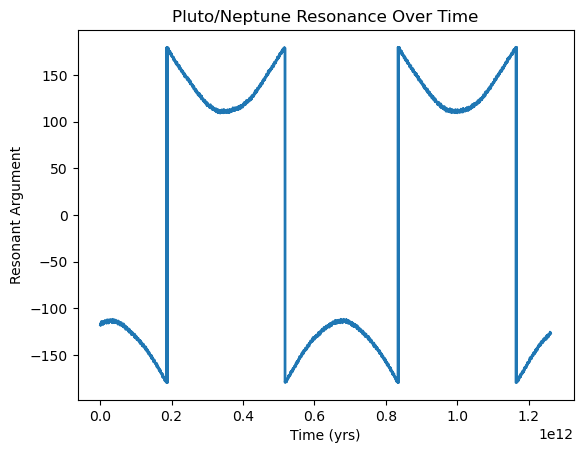

In [288]:
timesYears = [time/365/24/3600 for time in times] 
plt.plot(times, resonanceData)
plt.xlabel("Time (yrs)")
plt.ylabel("Resonant Argument")
plt.title("Pluto/Neptune Resonance Over Time")

Text(0.5, 1.0, 'Pluto/Neptune Period Ratio over Time')

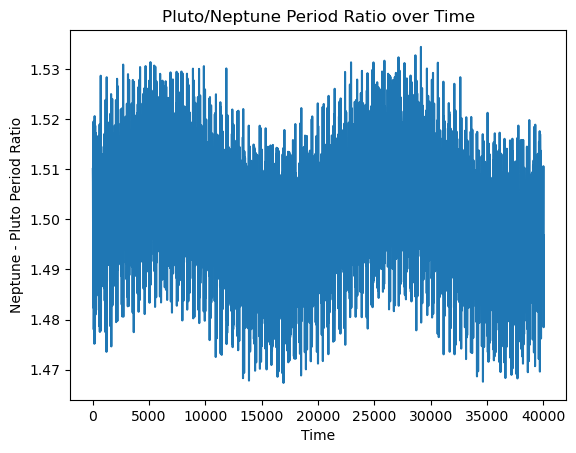

In [289]:
fig, ax = plt.subplots()

ax.plot(timesYears, periodRatios)
ax.set_xlabel("Time")
ax.set_ylabel("Neptune - Pluto Period Ratio")
ax.set_title("Pluto/Neptune Period Ratio over Time")

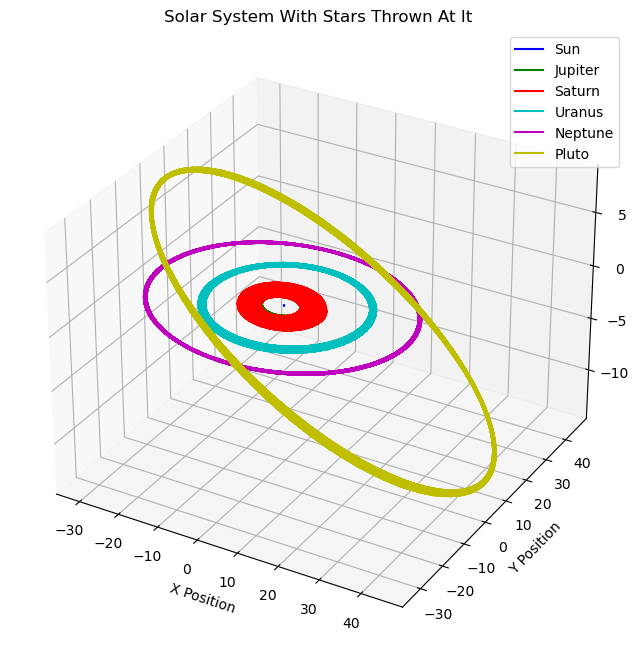

In [140]:
plotTracks3D(times, positionalData)

This graph is genuinely so shit, but we'll get there eventually. For now, we mainly care about the libration.

# Now We Add Planet 9

First we begin by adding some parameters to Planet 9.

In [290]:
#Semi-Major Axis
P9aMin = 380*au2m
P9aMax = 980*au2m

#Perastrum
P9PeriMin = 150*au2m
P9PeriMax = 350*au2m

#Mass
P9mMin = 5*mEarth_kg
P9mMax = 20*mEarth_kg

P9I = 0.523599 #This is approximately 30 degrees in radians; maybe we can add a bit of error to it down the line

#Some lists of default Planet 9 values
planet9ValsMin = [P9aMin, P9PeriMin, P9mMin, P9I]
planet9ValsMax = [P9aMax, P9PeriMax, P9mMax, P9I]

In [291]:
#Pretty simple, really
def addPlanet9(sim, parameterList = planet9ValsMin):
    SemiMajorAxis = parameterList[0]
    Perastrum = parameterList[1]
    Mass = parameterList[2]
    Inclination = parameterList[3]
    Eccentricity = 1-Perastrum/SemiMajorAxis

    #Randomize omega, so that we don't bias the system by putting Planet 9 in a particular position
    pomegaParam = np.random.rand() * np.pi

    sim.add(m=Mass, a = SemiMajorAxis, e = Eccentricity, inc = Inclination, pomega = pomegaParam)
    return sim

So! The plan is, we first see if Planet 9 ruins the resonance by existing. It stands to reason that the minimum parameters are likely the ones most likely to endanger the resonance, so let's test those. First, let's go ahead and revise the runsim program!

In [292]:
#This function will run a basic simulation of the solar system and track the positions of the particles, as well as the resonant argument of Pluto and Neptune
def runSimWithP9(endTime, timeSteps, sunMass = mSun_kg, planetsData = planetsDict, planet9Data = planet9ValsMin): #Input time in years; will be converted to seconds
    #Note for inputs - defining aList, eList, massList, and starMass ahead of time allows for cutting down on arguments
    #Boot up the simulation
    sim = rebound.Simulation()
    sim.units = ('m', 's', 'kg')

    #Add the star
    sim.add(m=sunMass)

    #Add our planets
    for stats in planetsData.values():
        sim.add(
            m=stats[0],
            a=stats[1],
            e=stats[2],
            inc=stats[3],
            Omega=stats[4],
            pomega=stats[5],
            M=stats[6]
        )
        
    sim.move_to_com()
    
    addPlanet9(sim, planet9Data)

    #allBodiesDict is our dictionary for tracking the positions of every body in the system
    allBodiesDict = {}
    allBodiesDict.update({"Sun":[]})
    for planetName in planetsData:
        allBodiesDict.update({planetName:[]})

    #Create our time array
    timeArray = np.linspace(0,endTime*years2sec,timeSteps)

    resList = []

    PRatioList = []

    for time in timeArray:
        print(f"Current year: {time/31536000} out of {endTime}")
        sim.integrate(time)
        sim.move_to_com()

        #Track where everything is
        allBodiesDict = trackBodies3D(time, allBodiesDict, sim)
        
        NeptuneOrbit = sim.particles[4].orbit(primary=sim.particles[0])
        PlutoOrbit = sim.particles[5].orbit(primary=sim.particles[0])
        
        lambdaN = NeptuneOrbit.M + NeptuneOrbit.pomega
        lambdaP = PlutoOrbit.M + PlutoOrbit.pomega
        
        phi = 3*lambdaP - 2*lambdaN - PlutoOrbit.pomega
        
        # Wrap to (-pi, pi]
        phi = np.arctan2(np.sin(phi), np.cos(phi))
        
        resList.append(np.degrees(phi))
        PRatioList.append(PlutoOrbit.P / NeptuneOrbit.P)


    #And now we're done!
    return timeArray, allBodiesDict, resList, PRatioList

In [293]:
times, positionalData, resonanceData, periodRatios = runSim(40000, 4000)

In [294]:
times, positionalData, resonanceData, periodRatios = runSimWithP9(40000, 4000)


Current year: 0.0 out of 40000
Current year: 10.009351875005787 out of 40000
Current year: 20.018703750011575 out of 40000
Current year: 30.028055625017362 out of 40000
Current year: 40.03740750002315 out of 40000
Current year: 50.04675937502894 out of 40000
Current year: 60.056111250034725 out of 40000
Current year: 70.06546312504051 out of 40000
Current year: 80.0748150000463 out of 40000
Current year: 90.08416687505209 out of 40000
Current year: 100.09351875005788 out of 40000
Current year: 110.10287062506366 out of 40000
Current year: 120.11222250006945 out of 40000
Current year: 130.12157437507526 out of 40000
Current year: 140.13092625008102 out of 40000
Current year: 150.1402781250868 out of 40000
Current year: 160.1496300000926 out of 40000
Current year: 170.1589818750984 out of 40000
Current year: 180.16833375010418 out of 40000
Current year: 190.17768562510997 out of 40000
Current year: 200.18703750011576 out of 40000
Current year: 210.19638937512153 out of 40000
Current year

Text(0.5, 1.0, 'Pluto/Neptune Resonance (P9 at Min Parameters)')

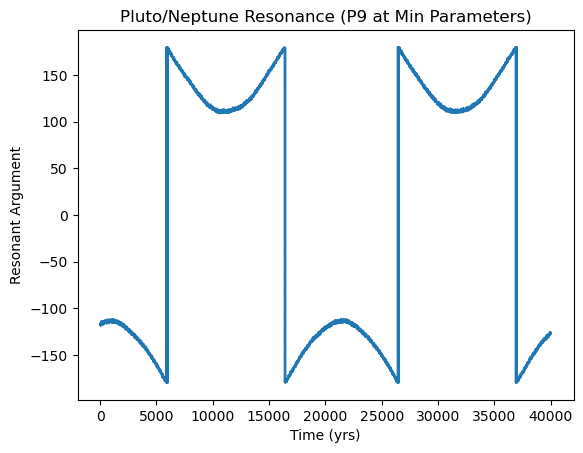

In [295]:
timesYears = [time/365/24/3600 for time in times]    

PlutoNeptuneTrueResonance = resonanceData

plt.plot(timesYears, resonanceData)
plt.xlabel("Time (yrs)")
plt.ylabel("Resonant Argument")
plt.title("Pluto/Neptune Resonance (P9 at Min Parameters)")

Text(0.5, 1.0, 'Pluto/Neptune Period Ratio (P9 at Min Parameters)')

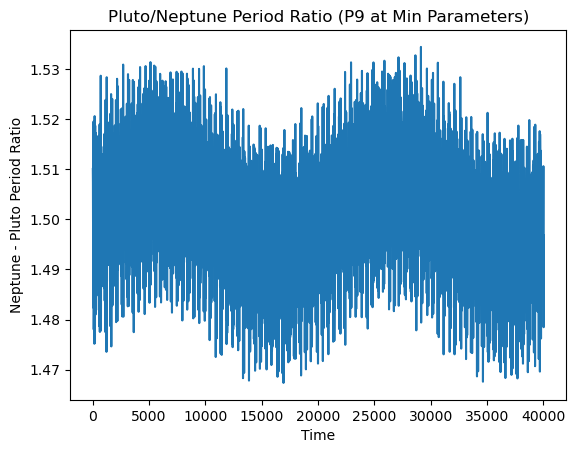

In [296]:
fig, ax = plt.subplots()

plutoNeptuneTrueRatio = periodRatios

ax.plot(timesYears, periodRatios)
ax.set_xlabel("Time")
ax.set_ylabel("Neptune - Pluto Period Ratio")
ax.set_title("Pluto/Neptune Period Ratio (P9 at Min Parameters)")

Yay! Looks like Planet 9 has no effect on the resonance at all. Expected, but certainly also useful, as it saves us the trouble of figuring out if we have to fight against the entire astrophysics community, or just ourselves. Now, let's make a test to see if the resonant arguent or the period ratio got messed with.

In [299]:
print(len(PlutoNeptuneTrueResonance), len(plutoNeptuneTrueRatio))

with open("defaultResonance.txt", "w") as output:
    output.write('\n'.join(str(item) for item in PlutoNeptuneTrueResonance) + '\n')

with open("defaultRatios.txt", "w") as output:
    output.write('\n'.join(str(item) for item in PlutoNeptuneTrueResonance) + '\n')

4000 4000


In [172]:
def goodResonance(resonanceData, periodRatioData, normalResArg = PlutoNeptuneTrueResonance, normalPRatio = plutoNeptuneTrueRatio):
    badResPoints = []
    badPPoints = []
    
    for x in range(3501, 4000):
        if abs(resonanceData[x]) < abs(PlutoNeptuneTrueResonance[x] * 0.95) or abs(resonanceData[x]) > abs(PlutoNeptuneTrueResonance[x] * 1.05):
            badResPoints.append(x)

        if abs(periodRatioData[x]) < abs(plutoNeptuneTrueRatio[x] * 0.95) or abs(periodRatioData[x]) > abs(plutoNeptuneTrueRatio[x] * 1.05):
            badPPoints.append(x)

    if len(badResPoints) == 0 and len(badPPoints) == 0:
        return True, badResPoints, badPPoints

    else: 
        return False, badResPoints, badPPoints

In [171]:
res, blah, bleh = goodResonance(resonanceData, periodRatios)
print(res)

True


# Upgraded Stellar Flyby Generator

Alright, first let's add everything we used for the basic flyby generator.

In [51]:
# Define mass range
m_min, m_max = 0.1, 3  # Solar masses
num_points = 10000
mass = np.linspace(m_min, m_max, num_points)  # Mass grid

# Compute normalization factor
N = 1.35 / (m_min**(-1.35) - m_max**(-1.35))

# Compute probability density function (PDF) using Salpeter IMF
delta_m = np.gradient(mass)  # Compute mass bin widths
pdfStellarMass = N * (mass**(-2.35)) * (delta_m / 1.0)

#Function to convert PDF to CDF
def pdf2cdf(pdf, x):
    delta_x = np.gradient(x) # Compute bin widths
    area = pdf * delta_x # Element-wise multiplication
    cdf = np.cumsum(area) # Cumulative sum to get CDF
    cdf /= cdf[-1]  # Normalize CDF

    return cdf

#Sampling Function
def sampling(numberSamples, cdf, x):
    randomNumbers = np.random.rand(numberSamples) # Generate random numbers
    indices = np.searchsorted(cdf, randomNumbers) #Binary search in CDF
    sampledx = x[indices] # Map to x-values
    sampledy = cdf[indices] #map to y-values

    return sampledx, sampledy

#Get our CDF
cdfStellarMass = pdf2cdf(pdfStellarMass, mass)

#First get our velocity range
v_min, v_max = 1, 140  #km/s
num_points_v = 10000
velocity = np.linspace(m_min, m_max, num_points_v)  # Velocity grid

#Now get our pdf
pdfVelocity = (velocity/(21**2) * np.exp((-velocity**2) / (2*(21**2))))

#Get our CDF
cdfVelocity = pdf2cdf(pdfVelocity, velocity)

#The amount of stuff in this function is probably redundant, but I kept running into weird errors when I tried to run it otherwise
def generateStars(numStars):
    #Get our mass sample using the Saltpeter Mass function
    mass = np.linspace(0.1, 3, 10000)  # Mass array
    N = 1.35 / (0.1**(-1.35) - 3**(-1.35))
    delta_m = np.gradient(mass)  # Compute mass bin widths
    pdfStellarMass = N * (mass**(-2.35)) * (delta_m / 1.0)
    cdfStellarMass = pdf2cdf(pdfStellarMass, mass)
    massSample = sampling(numStars, cdfStellarMass, mass)


    #Now for velocity
    velocity = np.linspace(10, 140, 10000)  # Velocity array
    pdfVelocity = (velocity/(21**2) * np.exp((-velocity**2) / (2*(21**2)))) #Rayleigh distribution
    cdfVelocity = pdf2cdf(pdfVelocity, velocity)
    vSample = sampling(numStars, cdfVelocity, velocity)


    massReturn = np.array(massSample[0])
    velocityReturn = np.array(vSample[0])

    return massReturn * mSun_kg , velocityReturn * 1000 #Convert to m/s

#This function will help with our modeling in a few places. There's probably one available on a library somewhere, but I figured it would
#be simplest to just make it myself.
def randomVector(magnitude):

    #Generate a random 3D vector
    random_rotation = R.random()
    random_direction = random_rotation.apply([0, 0, 1])


    #Convert to cartesian coordinates
    xVal = magnitude*random_direction[0]
    yVal = magnitude*random_direction[1]
    zVal = magnitude*random_direction[2]

    #Return the vector as a list
    return [xVal, yVal, zVal]

Now we add the actual function:

In [57]:
#Now for the actual flyby function. This thing decides the direction of a star's initial velocity, then spawns a star with the inputted mass
# and velocity on that trajectory.

def addFlybyStarRealistic(infoDict, mass, speed, sim, distance = 52000*au2m, maxDotProduct = 0, verbose = False):
    #Generate initial condition using spherical coordinates. We'll generate all stars at a constant distance from the sun.
    #To start with, we'll make it completely random where they start on the outer sphere.
    sunPos = infoDict["Sun"][-1]
    posVector = randomVector(distance)
    starPos = [(sunPos[0] + posVector[0]), (sunPos[1] + posVector[1]), (sunPos[2] + posVector[2])]

    #Now let's get our velocity vector going
    goodVector = False

    while goodVector == False:
        #Generate a position vector
        vVector = randomVector(speed)

        normV = vVector/np.sqrt(vVector[0]**2 + vVector[1]**2 + vVector[2]**2)
        normPos = starPos/np.sqrt(starPos[0]**2 + starPos[1]**2 + starPos[2]**2)

        #Now compare to the position vector. We can find the minimum allowed vector 
        dotProduct = (normV[0]*normPos[0] + normV[1]*normPos[1] + normV[2]*normPos[2])            
            
        if dotProduct <= maxDotProduct:
            goodVector = True


    sim.add(m = mass,
            x = starPos[0],
            y = starPos[1],
            z = starPos[2],
            vx = -vVector[0],
            vy = -vVector[1],
            vz = -vVector[2]
           )
    starName = "Flyby Star"

    if verbose == True:
        print("Star spawned with mass of", mass, "and a velocity of", speed, "generated.")
        print("Star position vector:", starPos)
        print("Star velocity vector:", vVector)
        print("Normalized dot product:", dotProduct)

    infoDict.update({starName:[]})


    return infoDict, sim

Alright, we need an actually good flyby generator. Fortunately, we have just the thing! This will generate a flyby the trajectory of which will begin at a distance of your choice and pass within a distance of your choice relative to the sun.

In [232]:
#First we need a function to do all of the evil linear algebra for us
def tiltVector(maxAngle, inputV):
    cosTheta = np.random.uniform(np.cos(maxAngle), 1.0)
    sinTheta = np.sqrt(1 - cosTheta**2)
    phi = np.random.uniform(0, 2*np.pi)

    randomV = np.array([
        sinTheta * np.cos(phi),
        sinTheta * np.sin(phi),
        cosTheta
    ])

    z = np.array([0.0, 0.0, 1.0])

    axis = np.cross(z, inputV)
    axis /= np.linalg.norm(axis)
    angle = np.arccos(np.dot(z, inputV))

    K = np.array([
        [0, -axis[2], axis[1]],
        [axis[2], 0, -axis[0]],
        [-axis[1], axis[0], 0]
    ])

    RodriguesMatrix = (
        np.eye(3)
        + np.sin(angle) * K
        + (1 - np.cos(angle)) * (K @ K)
    )

    FinalV = RodriguesMatrix @ randomV

    return FinalV

#And now we get to generate the actual flyby!
def addFlybyStarUpgraded(infoDict, mass, speed, sim, spawnDistance = 52000*au2m, maxDistance = 6000*au2m, verbose = False):
    #Generate initial condition using spherical coordinates. We'll generate all stars at a constant distance from the sun.
    #To start with, we'll make it completely random where they start on the outer sphere.
    sunPos = np.array(infoDict["Sun"][-1])
    posVector = np.array(randomVector(spawnDistance))
    starPos = np.array([(sunPos[0] + posVector[0]), (sunPos[1] + posVector[1]), (sunPos[2] + posVector[2])])

    print(sunPos/au2m, starPos/au2m)

    #Now let's get our velocity vector going
    print(spawnDistance, maxDistance)
    maxAngle = np.arctan(spawnDistance/maxDistance)

    invertedVector = posVector/-spawnDistance

    vDirection = tiltVector(maxAngle, invertedVector)
    vVector = vDirection * speed

    sim.add(m = mass,
            x = starPos[0],
            y = starPos[1],
            z = starPos[2],
            vx = vVector[0],
            vy = vVector[1],
            vz = vVector[2]
           )
    starName = "Flyby Star"

    if verbose == True:
        print("Star with mass of", mass, "and a velocity of", speed, "generated.")
        print("Star position vector:", starPos)
        print("Star velocity vector:", vVector)
        print("Normalized dot product:", dotProduct)

    infoDict.update({starName:[]})


    return infoDict, sim

Alright. That's our basic flyby generator from the semester, but perhaps we can do better. The most important thing is going to be finally figuring out how we can start the sim from a long distance, with good randomness, and still have a reasonable flyby.

In [53]:
#First get our velocity range
v_min, v_max = 1, 140  #km/s
num_points_v = 10000
velocity = np.linspace(m_min, m_max, num_points_v)  # Velocity grid

#Now get our pdf
pdfVelocity = (velocity/(21**2) * np.exp((-velocity**2) / (2*(21**2))))

#Get our CDF
cdfVelocity = pdf2cdf(pdfVelocity, velocity)

#The amount of stuff in this function is probably redundant, but I kept running into weird errors when I tried to run it otherwise
def generateStars(numStars):
    #Get our mass sample using the Saltpeter Mass function
    mass = np.linspace(0.1, 3, 10000)  # Mass array
    N = 1.35 / (0.1**(-1.35) - 3**(-1.35))
    delta_m = np.gradient(mass)  # Compute mass bin widths
    pdfStellarMass = N * (mass**(-2.35)) * (delta_m / 1.0)
    cdfStellarMass = pdf2cdf(pdfStellarMass, mass)
    massSample = sampling(numStars, cdfStellarMass, mass)


    #Now for velocity
    velocity = np.linspace(10, 140, 10000)  # Velocity array
    pdfVelocity = (velocity/(21**2) * np.exp((-velocity**2) / (2*(21**2)))) #Rayleigh distribution
    cdfVelocity = pdf2cdf(pdfVelocity, velocity)
    vSample = sampling(numStars, cdfVelocity, velocity)


    massReturn = np.array(massSample[0])
    velocityReturn = np.array(vSample[0])

    return massReturn * mSun_kg , velocityReturn * 1000 #Convert to m/s

Next, we add our functions for checking for issues. We'll use these in cooperation with the new checker.

In [54]:
#It will also be useful to check which (if any) of the planets have been ejected. To do this, we monitor their eccentricity:
def checkForEjection(sim, maxPlanetIndex, infoDict):
    ejectedIndices = []

    for x in range(1, maxPlanetIndex): #Every planet; we start at 1 to skip the sun
        eccentricity = sim.particles[x].e
        if eccentricity > 1 or eccentricity < 0:
            ejectedIndices.append(x)

    return ejectedIndices

def checkForPerturbation(sim, maxPlanetIndex, startingEccentricityVals, infoDict):
    skewedIndices = []

    for x in range(1, maxPlanetIndex): #Every planet; we start at 1 to skip the sun
        eccentricity = sim.particles[x].e
        #Check whether the new eccentricity is significantly larger or smaller than the previous value
        if eccentricity > 1.1*startingEccentricityVals[x] or eccentricity < 0.9*startingEccentricityVals[x]:
            skewedIndices.append(x)

    return skewedIndices

Now we add all of this functionality into our runSim function:

In [274]:
#This function will run a basic simulation of the solar system and track the positions of the particles, as well as the resonant argument of Pluto and Neptune
def runSimWithP9(endTime, timeSteps, spawnDist = 52000*au2m, maxDist = 6000*au2m, sunMass = mSun_kg, planetsData = planetsDict, planet9Data = planet9ValsMax, Verbose = False): #Input time in years; will be converted to seconds
    #Note for inputs - defining aList, eList, massList, and starMass ahead of time allows for cutting down on arguments
    #Boot up the simulation
    sim = rebound.Simulation()
    sim.units = ('m', 's', 'kg')

    #Add the star
    sim.add(m=sunMass)

    #Add our planets
    for stats in planetsData.values():
        sim.add(
            m=stats[0],
            a=stats[1],
            e=stats[2],
            inc=stats[3],
            Omega=stats[4],
            pomega=stats[5],
            M=stats[6]
        )
        
    sim.move_to_com()
    
    addPlanet9(sim, planet9Data)

    #allBodiesDict is our dictionary for tracking the positions of every body in the system
    allBodiesDict = {}
    allBodiesDict.update({"Sun":[]})
    for planetName in planetsData:
        allBodiesDict.update({planetName:[]})

    numPlanets = len(planetsData) - 1

    planetEccentricities = {}
    dumbWorkaroundCounter = 0

    for planetName in allBodiesDict.keys():
        #Store all planets' eccentricities
        if dumbWorkaroundCounter > 0 and dumbWorkaroundCounter <= numPlanets:
            planetEccentricities.update({str(planetName):sim.particles[dumbWorkaroundCounter].e})
        dumbWorkaroundCounter += 1


    #Create our time array
    timeArray = np.linspace(0,endTime*years2sec,timeSteps)

    spawnInterval = (endTime*years2sec)/4

    #This sets the next spawntime
    resList = []

    PRatioList = []

    exoStarMass, exoStarV = generateStars(1)
    
    starSpawned = False

    sunStarDists = []

    for time in timeArray:

        #Check if we're due to spawn a star
        if time >= spawnInterval and starSpawned == False:
            #Now create a new star!
            allBodiesDict, sim = addFlybyStarUpgraded(
                allBodiesDict,
                exoStarMass, 
                #exoStarV, 
                100000,
                sim, 
                spawnDistance = spawnDist, 
                maxDistance = maxDist, 
                verbose = Verbose
                )
            
            starSpawned = True


        if starSpawned == True:
            sunStarDist = np.sqrt((sim.particles[0].x - sim.particles[-1].x)**2 + (sim.particles[0].y - sim.particles[-1].y)**2 + (sim.particles[0].z - sim.particles[-1].z)**2)

            sunStarDists.append(sunStarDist)
            print(sunStarDist)
            
        print(f"Current year: {time/31536000} out of {endTime}")

        sim.integrate(time)
        sim.move_to_com()

        #Track where everything is
        allBodiesDict = trackBodies3D(time, allBodiesDict, sim)
        
        NeptuneOrbit = sim.particles[4].orbit(primary=sim.particles[0])
        PlutoOrbit = sim.particles[5].orbit(primary=sim.particles[0])
        
        lambdaN = NeptuneOrbit.M + NeptuneOrbit.pomega
        lambdaP = PlutoOrbit.M + PlutoOrbit.pomega
        
        phi = 3*lambdaP - 2*lambdaN - PlutoOrbit.pomega
        
        # Wrap to (-pi, pi]
        phi = np.arctan2(np.sin(phi), np.cos(phi))
        
        resList.append(np.degrees(phi))
        PRatioList.append(PlutoOrbit.P / NeptuneOrbit.P)


    #Now let's see what the damage is. First we check for ejections and perturbations
    dumbWorkaroundCounter = 0
    planetEccentricitiesFinal = {}
    ejectedPlanets = []
    perturbedPlanets = []

    for planetName in allBodiesDict.keys():
        if dumbWorkaroundCounter > 0 and dumbWorkaroundCounter <= numPlanets:
            planetEccentricitiesFinal.update({str(planetName):sim.particles[dumbWorkaroundCounter].e})
            if sim.particles[dumbWorkaroundCounter].e > 1:
                ejectedPlanets.append(planetName)
            elif sim.particles[dumbWorkaroundCounter].e > 1.1*planetEccentricities[str(planetName)] or sim.particles[dumbWorkaroundCounter].e < 0.9*planetEccentricities[str(planetName)]:
                perturbedPlanets.append(planetName)
        
        dumbWorkaroundCounter += 1

    #Now we check for any issues with Neptune's resonance with Pluto
    resonanceStatus, badRes, badRat = goodResonance(resList, PRatioList)
    
    print(f"Maximum distance from Sun to flyby star: {np.max(sunStarDists)/au2m} AU \n Minimum distance from Sun to flyby star: {np.min(sunStarDists)/au2m} AU")

    #And now we're done!
    return timeArray, allBodiesDict, resonanceStatus, ejectedPlanets, perturbedPlanets

In [276]:
times, positionalData, resonance, ejectedList, perturbedList = runSimWithP9(endTime = 100000, timeSteps = 4000, spawnDist = 52000*au2m, maxDist = 6000*au2m)
print(f"Ejections: {ejectedList}")
print(f"Perturbations: {perturbedList}")

Current year: 0.0 out of 100000
Current year: 25.02337968751447 out of 100000
Current year: 50.04675937502894 out of 100000
Current year: 75.0701390625434 out of 100000
Current year: 100.09351875005788 out of 100000
Current year: 125.11689843757236 out of 100000
Current year: 150.1402781250868 out of 100000
Current year: 175.1636578126013 out of 100000
Current year: 200.18703750011576 out of 100000
Current year: 225.21041718763024 out of 100000
Current year: 250.23379687514472 out of 100000
Current year: 275.2571765626592 out of 100000
Current year: 300.2805562501736 out of 100000
Current year: 325.3039359376881 out of 100000
Current year: 350.3273156252026 out of 100000
Current year: 375.35069531271705 out of 100000
Current year: 400.3740750002315 out of 100000
Current year: 425.397454687746 out of 100000
Current year: 450.4208343752605 out of 100000
Current year: 475.44421406277496 out of 100000
Current year: 500.46759375028944 out of 100000
Current year: 525.4909734378039 out of 100

These graphs are getting rather unclear. Maybe we can fix that.

In [277]:
def plotFlybyTracks(timeArray, posDict):
    fig = plt.figure(figsize=(8,8))
    ax = fig.add_subplot(projection='3d')
    legendList = []
    legendIndex = 0

    #Let's do it first for the Sun
    name = "Sun"

    posList = posDict[name]

    legendList.append(str(name))


    partTime = [entry[0] for entry in posList] #We're storing time, so we can use that for data later on if we so choose
    partX = [entry[1]/au2m for entry in posList]
    partY = [entry[2]/au2m for entry in posList]
    partZ = [entry[3]/au2m for entry in posList]

    ax.scatter(partX, partY, partZ, c=timeArray, cmap='viridis', s=10)


    name = "Flyby Star"

    posList = posDict[name]

    timeSpan = len(timeArray)
    lilTimeArray = np.linspace(timeArray[int(timeSpan/4)], timeArray[-1], int(timeSpan * 0.75))

    legendList.append(str(name))

    partTime = [entry[0] for entry in posList] #We're storing time, so we can use that for data later on if we so choose
    partX = [entry[1]/au2m for entry in posList]
    partY = [entry[2]/au2m for entry in posList]
    partZ = [entry[3]/au2m for entry in posList]

    ax.scatter(partX, partY, partZ, c=lilTimeArray, cmap='inferno', s=10)

    ax.set_xlabel('X Position (AU)')
    ax.set_ylabel('Y Position (AU)')
    ax.set_zlabel('Z Position (AU)')
    ax.legend(legendList)
    ax.set_title('Solar System With Stars Thrown At It')
    plt.show(); 

False


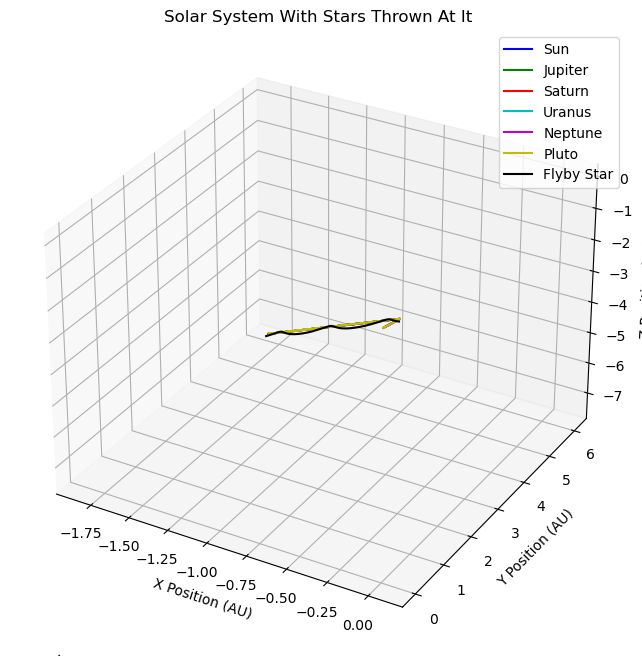

In [278]:
print(resonance)
plotTracks3D(times, positionalData)

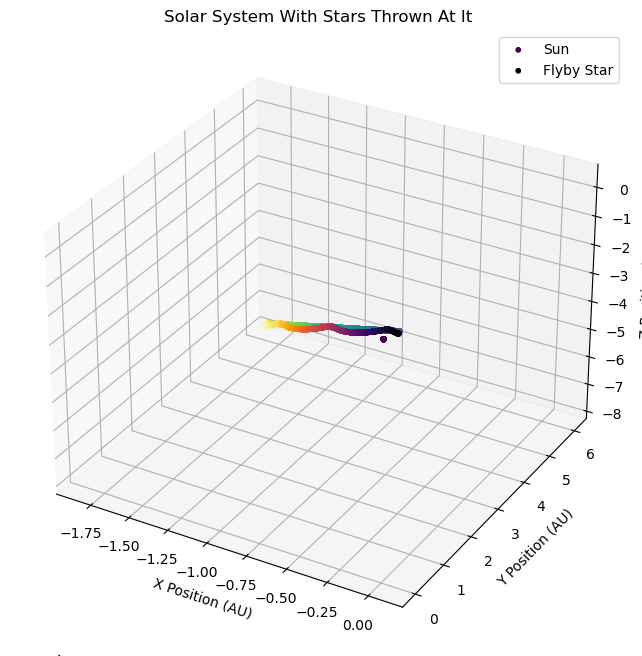

In [279]:
plotFlybyTracks(times, positionalData)

In [91]:
# maxDotProducts = np.linspace(-0.99, -0.90, 100)
# massList, vList = generateStars(1000)

# planet9EccentricityDiffs = []
# neptuneEccentricityDiffs = []
# minFlybyDists = []
# minFlybyDistsToP9 = []
# planet9EjectionDists = []
# innerPlanetEjectionDists = []
# starIndex = 0

# for dotProduct in maxDotProducts:
#     for iteration in range(10):
#         print(f"Max dot product: {dotProduct}, iteration: {iteration}")
#         times, bodiesDict, ejectionList, eccentricityDict, eccentricityDictFinal = runSimWithPlanet9(
#             endTime = 50000, 
#             timeSteps = 10, 
#             starMass = mSun_kg, 
#             exoStarMass = massList[starIndex], 
#             planetsData = solarSystemDict, 
#             planet9Data = [P9aMin, P9PeriMin, P9mMin, P9I], 
#             starSpeed = vList[starIndex], 
#             spawnDist = 1000*au2m,
#             MaxDotProduct = dotProduct
#             ) #Input time in years; will be converted to seconds

#         starIndex += 1

#         planet9EccentricityDiffs.append(np.abs(eccentricityDictFinal["Planet 9"] - eccentricityDict["Planet 9"]))
#         neptuneEccentricityDiffs.append(np.abs(eccentricityDictFinal["Neptune"] - eccentricityDict["Neptune"]))
        
#         minFlybyDist = flybyDist(bodiesDict)

#         minFlybyDists.append(minFlybyDist)

#         minFlybyDistToP9 = flybyDist(bodiesDict, "Planet 9")

#         minFlybyDistsToP9.append(minFlybyDistToP9)

#         #Now track any ejections
#         if "Planet 9" in ejectionList:
#             planet9EjectionDists.append(minFlybyDist)
#             if len(ejectionList) > 1:
#                 innerPlanetEjectionDists.append(minFlybyDist)
        
#         elif len(ejectionList) > 0:
#             innerPlanetEjectionDists.append(minFlybyDist)

Max dot product: -0.99, iteration: 0


NameError: name 'runSimWithPlanet9' is not defined

In [ ]:
#Now for the actual flyby function. This thing decides the direction of a star's initial velocity, then spawns a star with the inputted mass
# and velocity on that trajectory.

def addFlybyStarUpgraded(infoDict, mass, speed, sim, distance = 52000*au2m, maxDistance = 6000*au2m, verbose = False):
    #Generate initial condition using spherical coordinates. We'll generate all stars at a constant distance from the sun.
    #To start with, we'll make it completely random where they start on the outer sphere.
    sunPos = infoDict["Sun"][-1]
    posVector = np.array(randomVector(distance))
    starPos = [(sunPos[0] + posVector[0]), (sunPos[1] + posVector[1]), (sunPos[2] + posVector[2])]

    cosTheta = np.random.uniform(np.cos(maxAngle), 1.0)
    sinTheta = np.sqrt(1 - cos_theta**2)
    phi = np.random.uniform(0, 2*np.pi)

    randomV = np.array([
        sin_theta * np.cos(phi),
        sin_theta * np.sin(phi),
            cos_theta
    ])

    z = np.array([0.0, 0.0, 1.0])

    axis = np.cross(z, v)
    axis /= np.linalg.norm(axis)
    angle = np.arccos(np.dot(z, v), -1.0, 1.0)

    K = np.array([
        [0, -axis[2], axis[1]],
        [axis[2], 0, -axis[0]],
        [-axis[1], axis[0], 0]
    ])

    RodriguesMatrix = (
        np.eye(3)
        + np.sin(angle) * K
        + (1 - np.cos(angle)) * (K @ K)
    )

    vVector = speed * (RodriguesMatrix @ randomV)

    sim.add(m = mass,
            x = starPos[0],
            y = starPos[1],
            z = starPos[2],
            vx = vVector[0],
            vy = vVector[1],
            vz = vVector[2]
           )
    starName = "Flyby Star"

    if verbose == True:
        print("Star spawned with mass of", mass, "and a velocity of", speed, "generated.")
        print("Star position vector:", starPos)
        print("Star velocity vector:", vVector)
        print("Normalized dot product:", dotProduct)

    infoDict.update({starName:[]})


    return infoDict, sim

In [206]:
maxDist = 5
distance = 100
sunPos = [0,0,0]
posVector = np.array(randomVector(distance))
starPos = [(sunPos[0] + posVector[0]), (sunPos[1] + posVector[1]), (sunPos[2] + posVector[2])]

print(starPos)

#Now let's get our velocity vector going
invertedVector = posVector/-distance
print(invertedVector)

maxAngle = np.arctan(maxDist/distance)
print(maxAngle)

[-2.727746680385329, -99.35545908655958, -11.002370096785272]
[0.02727747 0.99355459 0.1100237 ]
0.049958395721942765
[-0.26109097  0.26605745  0.92792507] 0.9999999984252741


In [210]:
#To find our new vector, we're going to generate a vector within theta of the z-axis, then rotate it onto our actual vector
angle = 0.8
inputVector = np.array([-0.26109097, 0.26605745, 0.92792507])


def tiltVector(maxAngle, inputV):
    cosTheta = np.random.uniform(np.cos(maxAngle), 1.0)
    sinTheta = np.sqrt(1 - cosTheta**2)
    phi = np.random.uniform(0, 2*np.pi)

    randomV = np.array([
        sinTheta * np.cos(phi),
        sinTheta * np.sin(phi),
        cosTheta
    ])

    z = np.array([0.0, 0.0, 1.0])

    axis = np.cross(z, inputV)
    axis /= np.linalg.norm(axis)
    angle = np.arccos(np.dot(z, inputV))

    K = np.array([
        [0, -axis[2], axis[1]],
        [axis[2], 0, -axis[0]],
        [-axis[1], axis[0], 0]
    ])

    RodriguesMatrix = (
        np.eye(3)
        + np.sin(angle) * K
        + (1 - np.cos(angle)) * (K @ K)
    )

    FinalV = RodriguesMatrix @ randomV

    return FinalV

def angle_between(v1, v2):
    v1_u = v1
    v2_u = v2
    return np.arccos(np.clip(np.dot(v1_u, v2_u), -1.0, 1.0))

for x in range(100):
    newVector = tiltVector(angle, inputVector)
    print(angle_between(inputVector, newVector))

0.7622701698612476
0.7998627176008817
0.785999597274855
0.46641810191874256
0.773737868016905
0.7831713182003516
0.6998790794811459
0.5045230010529075
0.5335712422973042
0.3427489699411701
0.7936108262307642
0.44292032963643535
0.6233653383400525
0.6556948705354801
0.4800795733880084
0.7190561687978373
0.569155588566824
0.6231163208792536
0.3268968056928345
0.5919230978765512
0.42684650740076097
0.3960308425128235
0.3782486860402711
0.40934796140353935
0.7779133989539746
0.651126859457664
0.17323114276009008
0.4226608560972473
0.2115641822301473
0.6819238998942762
0.4905224411821302
0.5889029784675757
0.6123705900340892
0.3393475025165363
0.6178508408121849
0.43957693778042944
0.20781217254182285
0.5200789458137878
0.569405324894197
0.6553528609339158
0.62544300360775
0.3404774599530295
0.45236731003998837
0.386824478409084
0.5264318612874911
0.6957125420183617
0.7955183125528241
0.6664716380046211
0.1886908061067453
0.3587817905086637
0.22010310206347894
0.40327302701291456
0.60599255